## SWE - PyOMP - SOLUTION

PyOMP brings the **OpenMP programming model** into Python. Inside a
`@numba.openmp.njit` function you write `with openmp("parallel for"):`
and the compiler emits the same kind of parallel-region IR that
`#pragma omp parallel for` produces in C.

This differs from the `@njit(parallel=True)` seen earlier, which is
**Numba's own parallel mode**. PyOMP is OpenMP itself, exposed as a
Python decorator. The directives port to
C / C++ / Fortran without translation.

**SOLUTION**

### Table of Contents

1. [Imports and the OpenMP runtime](#sec1)
2. [The threading probe](#sec2)
3. [The step kernel with `openmp("parallel for")`](#sec3)
4. [Acceptance and timing](#sec4)
5. [Thread scaling](#sec5)
6. [Scaling with data size](#sec6)

### <a id="sec1"></a>1. Imports and the OpenMP runtime

`numba.openmp` exposes both the decorator and the runtime helpers. Set
the thread count once with `omp_set_num_threads(N)` before the first
parallel region.

---

**Quick Docs**

- Use the PyOMP-aware decorator:
  ```python
  from numba.openmp import (
      njit,
      openmp_context as openmp,
      omp_set_num_threads,
      omp_get_thread_num, omp_get_num_threads,
  )
  ```
- `with openmp("..."):` accepts any OpenMP construct (`parallel for`,
  `reduction(+:x)`, `target teams distribute`, …)
  at JIT time.
- `omp_set_num_threads(N)` sets the thread team size. This is equivalent to
  `OMP_NUM_THREADS=N` in C.


In [1]:
import os

# Pin OpenMP threads to cores before the runtime starts
os.environ.setdefault("OMP_PROC_BIND", "close")
os.environ.setdefault("OMP_PLACES", "cores")

import time

import numpy as np
import matplotlib.pyplot as plt
import numba
import psutil

# PyOMP exposes its own njit decorator at numba.openmp.njit
from numba.openmp import njit
from numba.openmp import openmp_context as openmp
from numba.openmp import (
    omp_get_thread_num,
    omp_get_num_threads,
    omp_set_num_threads,
)

import swe_core


# Shared problem parameters
N       = 16384
L       = 10.0
H0      = 1.0
AMP     = 0.1
SIG     = 0.5
CFL     = 0.4
G       = 9.81
N_STEPS = 1000
dx      = L / N
DT      = swe_core.fixed_dt(H0 + AMP, dx, cfl=CFL, g=G)

# Float64 NumPy reference for validation
h_ref, _ = swe_core.solve_numpy(N, N_STEPS)

### <a id="sec2"></a>2. The threading probe

Confirm we got the requested team size by asking the OpenMP runtime
inside a `parallel` region. We request one thread per physical core and
expect to observe that same count inside the region.

---

**Quick Docs**

- `omp_get_thread_num()` / `omp_get_num_threads()`: this thread's id and
  the team size, valid inside a `parallel` region.

In [2]:
N_THREADS = psutil.cpu_count(logical=False) or os.cpu_count()
omp_set_num_threads(N_THREADS)

@njit
def probe_threading():
    '''Inside an `openmp("parallel")` region, ask how many threads we got.'''
    n_seen = 0
    with openmp("parallel"):
        if omp_get_thread_num() == 0:
            n_seen = omp_get_num_threads()
    return n_seen

n_observed = probe_threading()
print(f'threads: requested {N_THREADS}, observed inside parallel: {n_observed}')

threads: requested 8, observed inside parallel: 8


### <a id="sec3"></a>3. The step kernel with `openmp("parallel for")`

Now, let's implement the same **Read / Compute / Update** shape for our problem, expressed in PyOMP:

- **Read**. Inside a `parallel for`, each thread reads `h[i-1]`, `h[i]`, `h[i+1]` for its slice of cells.
- **Compute**. `rusanov_face(...)` is called twice per cell, for the west and east face.
- **Update**. `h_new[i] = h[i] - (dt/dx) * (Fh_e - Fh_w)`. Each thread writes its own range of `h_new`, so no synchronisation is needed because the iteration space is partitioned.

The per-face flux lives in its own `@njit` helper so the parallel-loop body stays compact. The code shape mirrors what you would write in C-OpenMP.

---

**Quick Docs**

- `with openmp("parallel for"):` parallelises the immediately-following `for` loop. Iterations are distributed across the thread team.
- `with openmp("parallel for reduction(+:total)"):` would parallelise a reduction. We don't use one here. The SWE step writes one output per cell, with no cross-cell accumulation.

In [3]:
DRY_TOL_F = 1e-6

@njit
def rusanov_face(hL, hR, huL, huR, g):
    '''Scalar Rusanov face flux. Pulled into its own @njit function so the
    parallel-loop body stays compact.'''
    hL_s = hL if hL > DRY_TOL_F else DRY_TOL_F
    hR_s = hR if hR > DRY_TOL_F else DRY_TOL_F
    uL = huL / hL_s
    uR = huR / hR_s
    cL = np.sqrt(g * hL_s)
    cR = np.sqrt(g * hR_s)
    a  = max(abs(uL) + cL, abs(uR) + cR)
    Fh  = 0.5 * (huL + huR) - 0.5 * a * (hR - hL)
    Fhu = 0.5 * (huL * uL + 0.5*g*hL*hL +
                 huR * uR + 0.5*g*hR*hR) - 0.5 * a * (huR - huL)
    return Fh, Fhu

@njit
def step_pyomp(h, hu, h_new, hu_new, dx, dt, g):
    '''One Rusanov-flux step. The per-cell loop is wrapped in
    `with openmp("parallel for")`.'''
    Np2 = h.shape[0]
    N   = Np2 - 2
    # Carry ghost cells through (the caller reapplies BCs between steps).
    h_new[0]  = h[0];  hu_new[0]  = hu[0]
    h_new[-1] = h[-1]; hu_new[-1] = hu[-1]
    inv = dt / dx
    with openmp("parallel for"):
        for i in range(1, N + 1):
            Fh_w, Fhu_w = rusanov_face(h[i-1], h[i],   hu[i-1], hu[i],   g)
            Fh_e, Fhu_e = rusanov_face(h[i],   h[i+1], hu[i],   hu[i+1], g)
            h_new[i]  = h[i]  - inv * (Fh_e  - Fh_w)
            hu_new[i] = hu[i] - inv * (Fhu_e - Fhu_w)

### <a id="sec4"></a>4. Acceptance and timing

Two pre-allocated buffers, swapped after each step so the loop allocates nothing. Wall-
clock is measured by `swe_core.timed_run`. Correctness against the
float64 NumPy reference uses `swe_core.max_diff`.

In [4]:
def run_pyomp() -> tuple[np.ndarray, np.ndarray]:
    h, hu = swe_core.bump_ic(N, L=L, h0=H0, amplitude=AMP, sigma=SIG)
    h2 = np.empty_like(h); hu2 = np.empty_like(hu)
    for _ in range(N_STEPS):
        swe_core.apply_bc_reflective(h, hu)
        step_pyomp(h, hu, h2, hu2, dx, DT, G)
        h, hu, h2, hu2 = h2, hu2, h, hu
    return h, hu

# Cold capture (includes Numba + PyOMP compile).
t0 = time.perf_counter()
h_pyomp, _ = run_pyomp()
cold_s = time.perf_counter() - t0

warm = swe_core.timed_run(run_pyomp, warmup=2, repeats=5, label='10_pyomp')

diff = swe_core.max_diff(h_ref, h_pyomp)
swe_core.report_and_verify(warm, diff, tol=1e-12, cold_s=cold_s,
                           n=N, steps=N_STEPS,
                           cold_note='incl. JIT + OMP region lowering')

swe_core.save_timing(
    warm, grid_str=f'N={N}', tool='pyomp', hardware='cpu',
    dtype='float64', steps=N_STEPS,
    cold_s=cold_s, max_diff_vs_numpy=diff,
    threads_observed=int(n_observed),
    numba_version=numba.__version__,
)

[10_pyomp] N=16384 steps=1000 | cold   155.7 ms (incl. JIT + OMP region lowering) | warm    20.5 ms | max_diff 0.00e+00 < tol 1e-12 | PASS


### <a id="sec5"></a>5. Thread scaling

The same kernel scales with `omp_set_num_threads(n)` with no recompile and
no Python-level thread orchestration. The sweep below runs up to the logical-core count.
The dotted line in the plot marks the physical-core count.

**Predict before run:** sketch speedup against thread count up to the
logical-core count. `N = 16384` keeps the working set in cache.


**The roof first.** Notebook 08 measured the DRAM ceiling with STREAM. Its
triad `a[i] = b[i] + s*c[i]` is a three-line PyOMP loop, which we can write
and check against.


In [ ]:
@njit
def triad(a, b, c, s, n):
    with openmp("parallel for"):
        for i in range(n):
            a[i] = b[i] + s * c[i]

N_TRIAD = 64 * 1024 * 1024                 # 3 x 512 MB: DRAM-resident
a_t = np.zeros(N_TRIAD); b_t = np.random.rand(N_TRIAD); c_t = np.random.rand(N_TRIAD)

t = swe_core.timed_run(triad, a_t, b_t, c_t, 3.0, N_TRIAD, warmup=1, repeats=10)
gbs = 3 * N_TRIAD * 8 / t['min_s'] / 1e9   # triad touches 3 arrays x 8 B per element
print(f'PyOMP  triad ({N_THREADS} threads): {gbs:5.1f} GB/s')
roof = swe_core.load_machine().get('cpu_stream_triad_gbs')
if roof:
    print(f'STREAM triad ({N_THREADS} threads): {roof:5.1f} GB/s')
del a_t, b_t, c_t

PyOMP  triad (8 threads):  45.4 GB/s
STREAM triad (8 threads):  45.1 GB/s


  threads =  1:   148.7 ms     110.2 Mcells/s


  threads =  2:    75.5 ms     217.1 Mcells/s
  threads =  4:    39.0 ms     420.3 Mcells/s


  threads =  8:    20.8 ms     788.5 Mcells/s
  threads = 16:    23.8 ms     687.2 Mcells/s


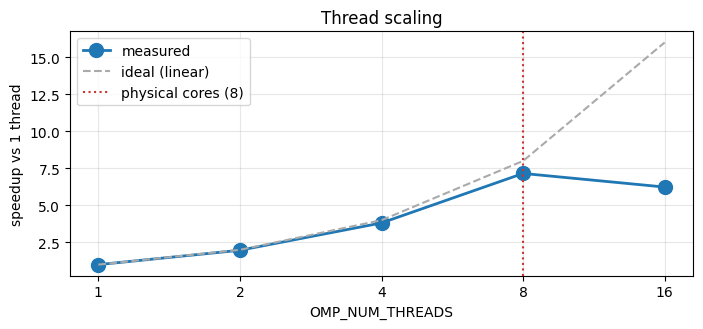

In [6]:
N_LOGICAL = os.cpu_count()
THREAD_COUNTS = [1]
while THREAD_COUNTS[-1] * 2 <= N_LOGICAL:
    THREAD_COUNTS.append(THREAD_COUNTS[-1] * 2)

sweep = []
for nthreads in THREAD_COUNTS:
    omp_set_num_threads(nthreads)
    r = swe_core.timed_run(run_pyomp, warmup=2, repeats=3)
    rate = N * N_STEPS / r['median_s'] / 1e6
    sweep.append((nthreads, r['median_s'], rate))
    print(f'  threads = {nthreads:>2}:  {r["median_s"]*1000:6.1f} ms   '
          f'{rate:7.1f} Mcells/s')

ns = [s[0] for s in sweep]
ts = [s[1] for s in sweep]
speedups = [ts[0] / t for t in ts]

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(ns, speedups, 'o-', linewidth=2, markersize=10, label='measured')
ax.plot(ns, ns,       '--', color='#aaa',           label='ideal (linear)')
ax.axvline(N_THREADS, color='#c33', linestyle=':',
           label=f'physical cores ({N_THREADS})')
ax.set_xscale('log', base=2)
ax.set_xticks(ns); ax.set_xticklabels([str(n) for n in ns])
ax.set_xlabel('OMP_NUM_THREADS'); ax.set_ylabel('speedup vs 1 thread')
ax.set_title('Thread scaling')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

omp_set_num_threads(N_THREADS)   # restore the notebook default for later cells


Speedup is near-linear as each new thread lands on an idle core,
and stops at the physical-core count. The SMT step from physical to logical
cores adds nothing here and can regress: sibling threads share the same cores.

At `N = 16384` the working set (4 arrays × 8 B ≈ 512 KiB) fits in one core's
L2 cache, so the step never touches DRAM. The limit is
arithmetic: `sqrt` and divide in a scalar compiled loop.

### <a id="sec6"></a>6. Scaling with data size

Let's now look at throughput against working-set size. Here one fused loop runs per step, so the working set is just the four
`float64` state arrays. The wall to watch for is the last-level cache, marked in the plot.

Unlike JAX, a new `N` triggers no recompile here. Numba specialises on `dtype` and rank, not shape, so there is no cold spike to chart.

**Q:** throughput is flat while the working set is cache-resident, from L2
through L3. What limits the kernel there? (Measured in notebook 14)

  N=   16,384:  working set      0.5 MiB    749.7 Mcells/s


  N=   65,536:  working set      2.0 MiB    829.5 Mcells/s


  N=  262,144:  working set      8.0 MiB    839.3 Mcells/s


  N=1,048,576:  working set     32.0 MiB    845.2 Mcells/s


  N=2,097,152:  working set     64.0 MiB    842.1 Mcells/s


  N=4,194,304:  working set    128.0 MiB    774.2 Mcells/s


  N=16,777,216:  working set    512.0 MiB    598.2 Mcells/s


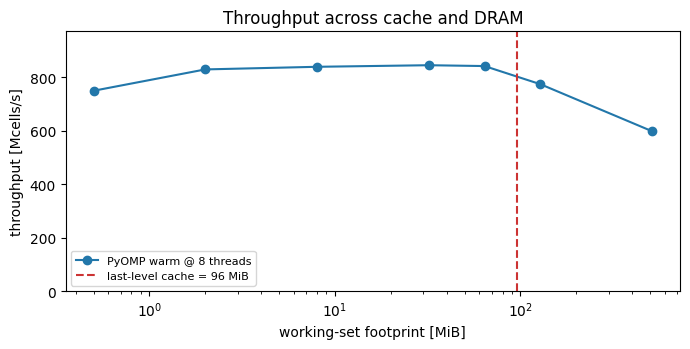

In [7]:
# Sweep across cache regimes. Few steps at large N keeps runtime bounded, throughput is step count-invariant.
SWEEP = [(16384, 1000), (65536, 1000), (262144, 500), (1048576, 200),
         (2097152, 100), (4194304, 50), (16777216, 20)]

grid_data = []
for N_local, steps_local in SWEEP:
    L_local  = 10.0
    dx_local = L_local / N_local
    DT_local = swe_core.fixed_dt(H0 + AMP, dx_local, cfl=CFL, g=G)

    # Run the IC outside timed function: only time update step.
    h0, hu0 = swe_core.bump_ic(N_local, L=L_local, h0=H0, amplitude=AMP, sigma=SIG)
    s0, s1 = np.empty_like(h0), np.empty_like(hu0)

    def run_at(h=h0, hu=hu0, h2=s0, hu2=s1, dx_=dx_local, dt_=DT_local, s_=steps_local):
        for _ in range(s_):
            swe_core.apply_bc_reflective(h, hu)
            step_pyomp(h, hu, h2, hu2, dx_, dt_, G)
            h, hu, h2, hu2 = h2, hu2, h, hu

    r = swe_core.timed_run(run_at, warmup=2, repeats=5)
    cells_per_s = N_local * steps_local / r['median_s']
    ws_mb = swe_core.to_mib(4 * (N_local + 2) * 8)   # 4 float64 arrays: h, hu, h_new, hu_new
    grid_data.append((N_local, cells_per_s, ws_mb))
    print(f'  N={N_local:>9,}:  working set {ws_mb:8.1f} MiB   '
          f'{cells_per_s/1e6:6.1f} Mcells/s')

ws      = [d[2] for d in grid_data]
rates   = [d[1] / 1e6 for d in grid_data]
LLC_MIB = swe_core.llc_mib() # Obtain CPU L3 cache size

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.semilogx(ws, rates, 'o-', color='#27a', label=f'PyOMP warm @ {N_THREADS} threads')
if LLC_MIB:
    ax.axvline(LLC_MIB, color='#c33', ls='--', label=f'last-level cache = {LLC_MIB:.0f} MiB')
ax.set_ylim(0, max(rates) * 1.15)
ax.set(xlabel='working-set footprint [MiB]', ylabel='throughput [Mcells/s]',
       title='Throughput across cache and DRAM')
ax.legend(loc='lower left', fontsize=8)
plt.tight_layout(); plt.show()

In [8]:
# Rates across the shared size range, for the synthesis notebook (14).
def run_pyomp_at(n_cells, n_steps):
    dx_ = 10.0 / n_cells
    dt_ = swe_core.fixed_dt(H0 + AMP, dx_, cfl=CFL, g=G)
    h, hu = swe_core.bump_ic(n_cells, L=10.0, h0=H0, amplitude=AMP, sigma=SIG)
    h2, hu2 = np.empty_like(h), np.empty_like(hu)
    for _ in range(n_steps):
        swe_core.apply_bc_reflective(h, hu)
        step_pyomp(h, hu, h2, hu2, dx_, dt_, G)
        h, hu, h2, hu2 = h2, hu2, h, hu
    return h

swe_core.save_sweep('10_pyomp', run_pyomp_at)

**Recap.**

- Same `#pragma omp parallel for` directives as C, exposed via a
  Python context manager.
- Thread scaling is near-linear up to the physical-core count and the SMT
  step adds nothing (Sec. 5); the kernel handles any `N` with no recompile
  (Sec. 6).

Next: `11__swe__nanobind.ipynb` drops into C++. We compile a
hand-written kernel and call it from Python through a binding library.
